In [1]:
import pandas as pd

In [2]:
import os
os.listdir(".")

['.config', 'Concrete_Data.xls', 'sample_data']

In [3]:
df = pd.read_excel("Concrete_Data.xls")

In [ ]:
df.shape

(1030, 9)

In [ ]:
df.head()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


In [4]:
col_rename = {'Cement (component 1)(kg in a m^3 mixture)':'cement',
'Blast Furnace Slag (component 2)(kg in a m^3 mixture)':'blast_furnace',
'Fly Ash (component 3)(kg in a m^3 mixture)':'fly_ash',
'Water  (component 4)(kg in a m^3 mixture)':'water',
'Superplasticizer (component 5)(kg in a m^3 mixture)':'superplasticizer',
'Coarse Aggregate  (component 6)(kg in a m^3 mixture)':'coarse_aggregate',
'Fine Aggregate (component 7)(kg in a m^3 mixture)':'fine_aggregate',
'Age (day)':'age',
'Concrete compressive strength(MPa, megapascals) ':'strength'}

df.rename(columns=col_rename,inplace=True)

In [5]:
df.columns

Index(['cement', 'blast_furnace', 'fly_ash', 'water', 'superplasticizer',
       'coarse_aggregate', 'fine_aggregate', 'age', 'strength'],
      dtype='object')

In [ ]:
df.head()

,cement,blast_furnace,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


In [ ]:
## Check basic stats
df.describe()

,cement,blast_furnace,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.165631,73.895485,54.187136,181.566359,6.203112,972.918592,773.578883,45.662136,35.817836
std,104.507142,86.279104,63.996469,21.355567,5.973492,77.753818,80.175427,63.169912,16.705679
min,102.000000,0.000000,0.000000,121.750000,0.000000,801.000000,594.000000,1.000000,2.331808
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.707115
50%,272.900000,22.000000,0.000000,185.000000,6.350000,968.000000,779.510000,28.000000,34.442774
75%,350.000000,142.950000,118.270000,192.000000,10.160000,1029.400000,824.000000,56.000000,46.136287
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.599225


In [ ]:
## Check if data have any null value
pd.isnull(df).sum()

,0
cement,0
blast_furnace,0
fly_ash,0
water,0
superplasticizer,0
coarse_aggregate,0
fine_aggregate,0
age,0
strength,0


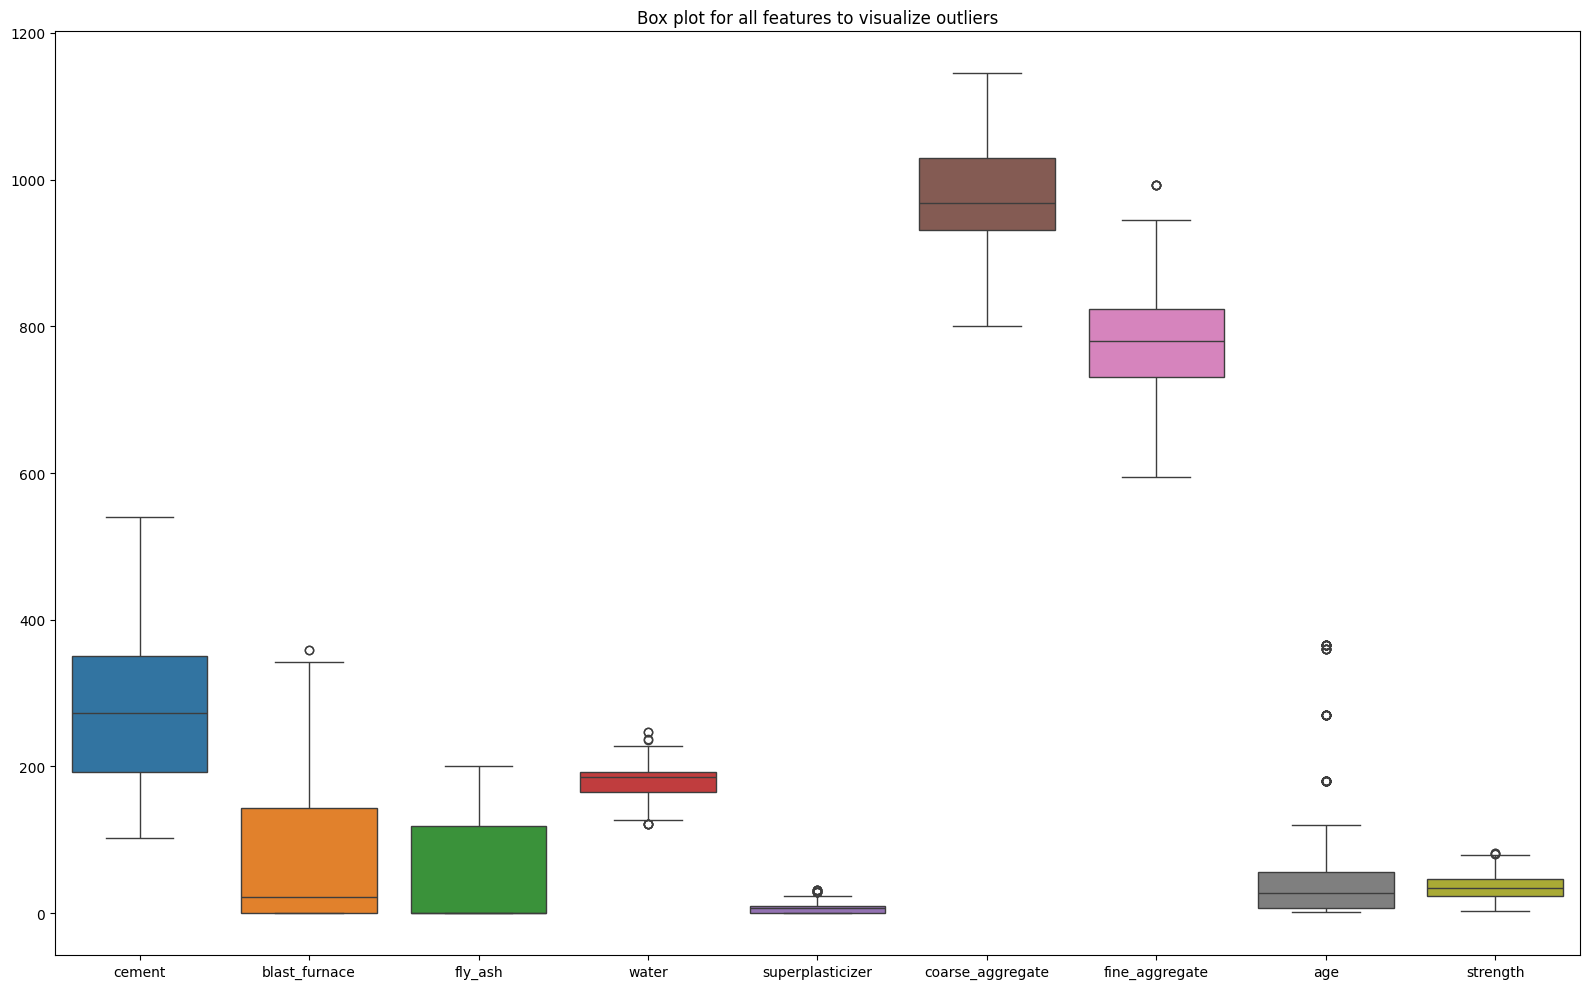

In [ ]:
## check if data have outliers
# IQR, Boxplot

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16,10))
sns.boxplot(data=df)
plt.title("Box plot for all features to visualize outliers")
plt.tight_layout()
plt.show()

In [7]:
outlier_summary = {}

for col in df.columns:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3-Q1
  lower_bound = Q1 - 1.5*IQR
  upper_bound = Q3 + 1.5*IQR
  outliers = df[(df[col]<lower_bound) | (df[col]>upper_bound)]
  outlier_summary[col] = len(outliers)
  print(f"{col} : {len(outliers)}")

cement : 0
blast_furnace : 2
fly_ash : 0
water : 9
superplasticizer : 10
coarse_aggregate : 0
fine_aggregate : 5
age : 59
strength : 4


In [ ]:
## Treatment of Outliers
'''
1. Leave them as it is - It may reflect real world variation
2. Remove outliers
3. Cap/Floor them
4. Use robust models which can handle outlier better -- XGBoost or any tree based model
'''

In [8]:
outlier_cols = [col for col in outlier_summary if outlier_summary[col]>0]
outlier_cols.remove('strength')
print(outlier_cols)

['blast_furnace', 'water', 'superplasticizer', 'fine_aggregate', 'age']


In [9]:
for col in outlier_cols:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3-Q1
  lower_bound = Q1 - 1.5*IQR
  upper_bound = Q3 + 1.5*IQR
  print(f"Rows before dropping outlier in column: {col} : {df.shape[0]}")
  df = df[(df[col]>=lower_bound) & (df[col]<=upper_bound)]
  print(f"Rows after dropping outlier in column: {col} : {df.shape[0]}")
  print("="*50)

Rows before dropping outlier in column: blast_furnace : 1030
Rows after dropping outlier in column: blast_furnace : 1028
Rows before dropping outlier in column: water : 1028
Rows after dropping outlier in column: water : 1019
Rows before dropping outlier in column: superplasticizer : 1019
Rows after dropping outlier in column: superplasticizer : 1009
Rows before dropping outlier in column: fine_aggregate : 1009
Rows after dropping outlier in column: fine_aggregate : 974
Rows before dropping outlier in column: age : 974
Rows after dropping outlier in column: age : 930


In [ ]:
df.columns

Index(['cement', 'blast_furnace', 'fly_ash', 'water', 'superplasticizer',
       'coarse_aggregate', 'fine_aggregate', 'age', 'strength'],
      dtype='object')

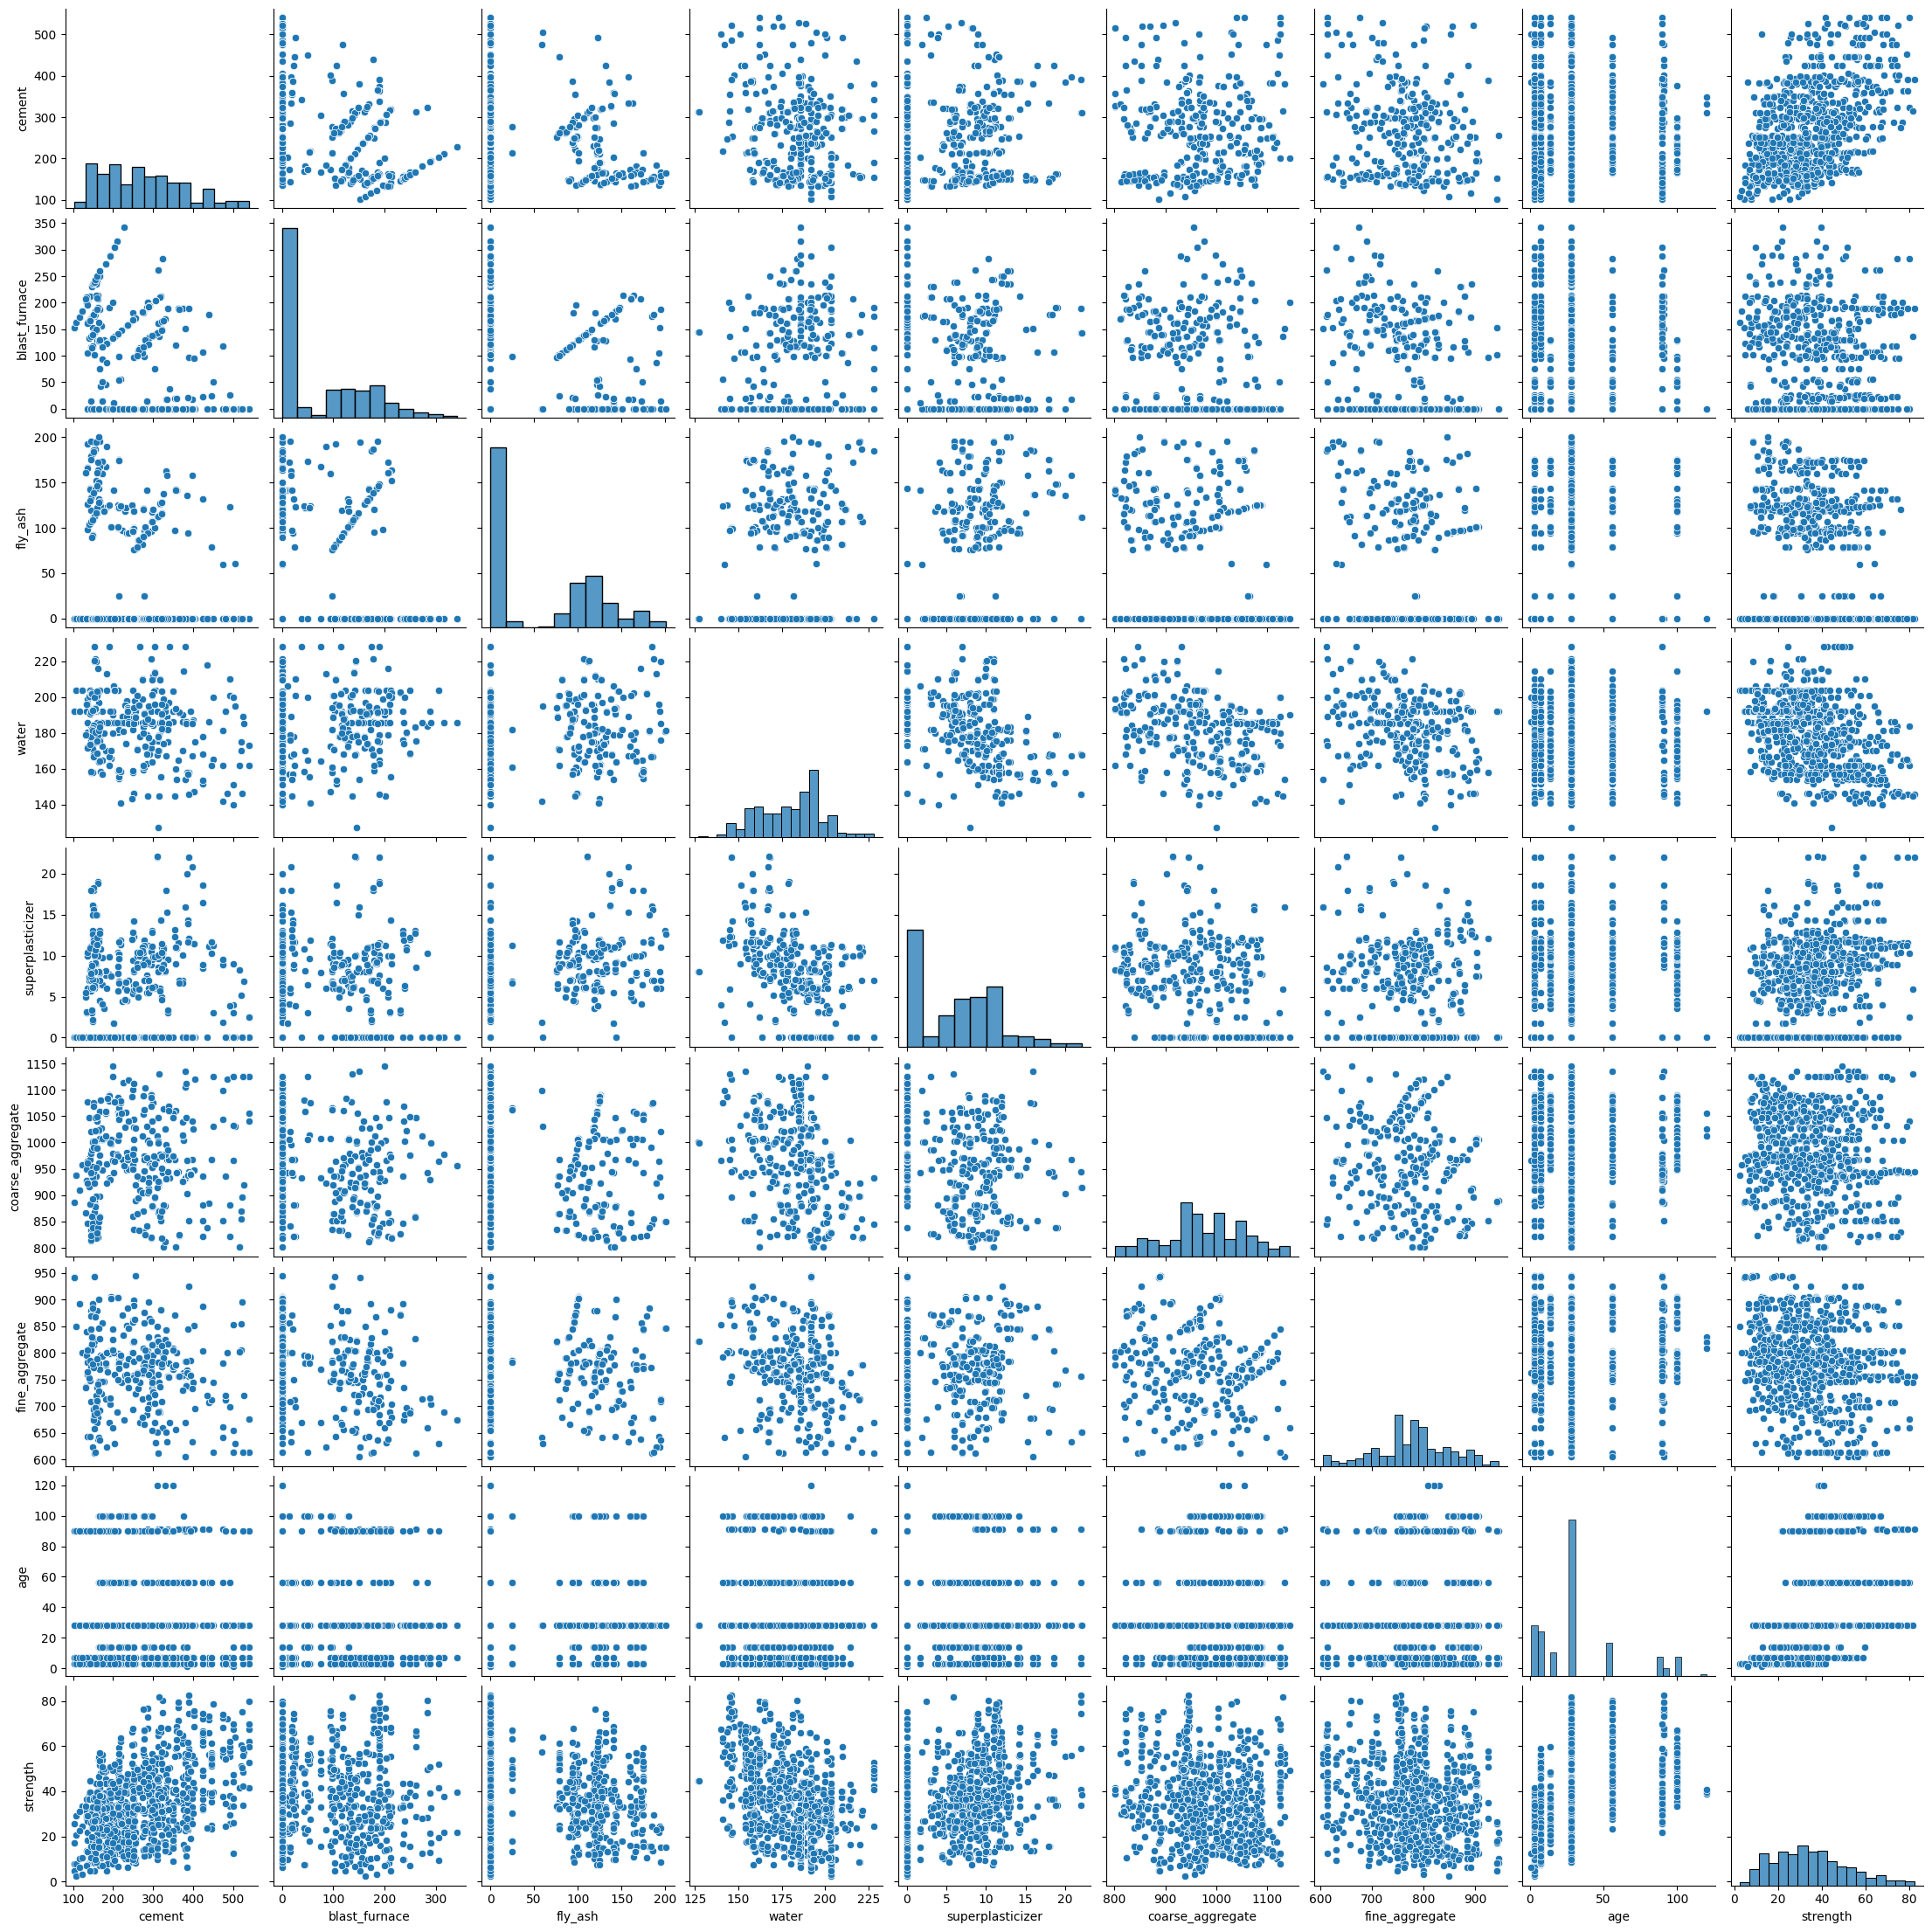

In [ ]:
sns.pairplot(df[df.columns.tolist()])

In [ ]:
df.columns

Index(['cement', 'blast_furnace', 'fly_ash', 'water', 'superplasticizer',
       'coarse_aggregate', 'fine_aggregate', 'age', 'strength'],
      dtype='object')

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X = df.drop('strength',axis=1)
y = df['strength']

In [12]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape,y_train.shape

((744, 8), (744,))

In [13]:
X_test.shape

(186, 8)

In [35]:
### 10-August-2025 code ####
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor

from sklearn.linear_model import Lasso, Ridge
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
import xgboost as xgb

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold, cross_val_score

In [21]:
models = {
    "Linear Regression":LinearRegression(),
    "Polynomial Refression (deg=2)": Pipeline(
                                                [
                                                    ("Poly",PolynomialFeatures(degree=2)),
                                                     ("linreg",LinearRegression())
                                                ]
                                              ),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.01),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100,random_state=42),
    "Gradient Boosting":GradientBoostingRegressor(n_estimators=100,random_state=42),
    "XGBoost":xgb.XGBRegressor(n_estimators=200,learning_rate=0.1, random_state=42)
}

In [22]:
results = {}

for name,model in models.items():
  print(f"Model: {name}")
  model.fit(X_train,y_train)
  y_pred = model.predict(X_test)
  results[name] = {
      "MAE":mean_absolute_error(y_test,y_pred),
      "MSE": mean_squared_error(y_test,y_pred),
      "R2": r2_score(y_test,y_pred)
  }

Model: Linear Regression
Model: Polynomial Refression (deg=2)
Model: Ridge Regression
Model: Lasso Regression
Model: Decision Tree
Model: Random Forest
Model: Gradient Boosting
Model: XGBoost


In [23]:
results

{'Linear Regression': {'MAE': 6.04290572909031,
  'MSE': 61.452975082871625,
  'R2': 0.763672183826869},
 'Polynomial Refression (deg=2)': {'MAE': 4.619613517634157,
  'MSE': 36.93328051364395,
  'R2': 0.8579668190819304},
 'Ridge Regression': {'MAE': 6.0429063316062,
  'MSE': 61.45298712499376,
  'R2': 0.7636721375168503},
 'Lasso Regression': {'MAE': 6.043062807490651,
  'MSE': 61.455157566367916,
  'R2': 0.7636637907172138},
 'Decision Tree': {'MAE': 4.445656519777104,
  'MSE': 53.99958591978396,
  'R2': 0.792335453288203},
 'Random Forest': {'MAE': 3.349544131681242,
  'MSE': 24.775471800688422,
  'R2': 0.904721730112825},
 'Gradient Boosting': {'MAE': 3.6407835682961567,
  'MSE': 26.351017034274253,
  'R2': 0.8986627042669126},
 'XGBoost': {'MAE': 3.1492323869093766,
  'MSE': 22.402929066584445,
  'R2': 0.9138457447333068}}

In [27]:
results_df = pd.DataFrame(results).T.sort_values(by="MSE")

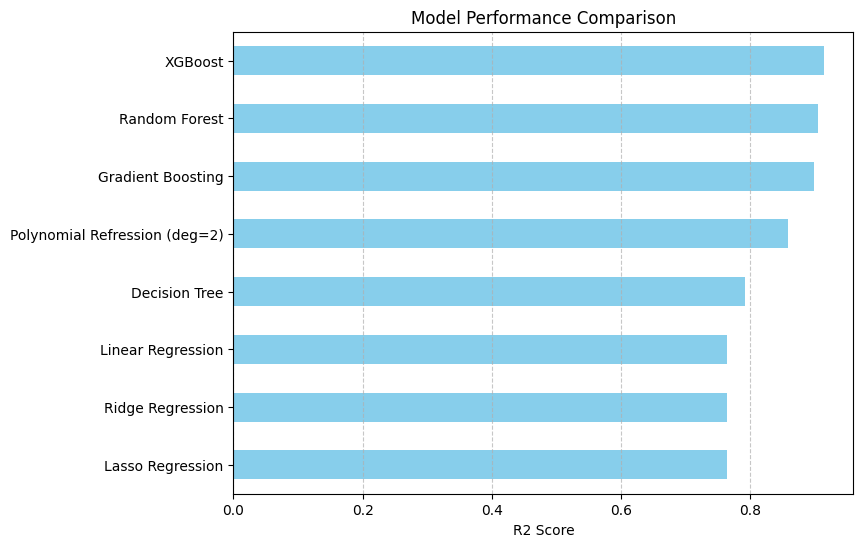

In [31]:
plt.figure(figsize=(8,6))
results_df["R2"].sort_values().plot(kind="barh",color="skyblue")
plt.xlabel("R2 Score")
plt.title("Model Performance Comparison")
plt.grid(axis="x",linestyle="--",alpha=0.7)
plt.show()

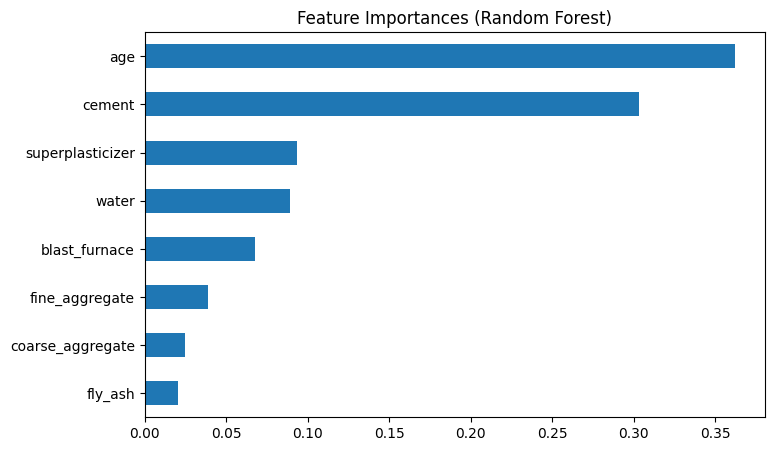

In [34]:
rf = models["Random Forest"]
rf_importances = pd.Series(rf.feature_importances_,index=X.columns)
rf_importances.sort_values().plot(kind='barh',figsize=(8,5), title="Feature Importances (Random Forest)")
plt.show()

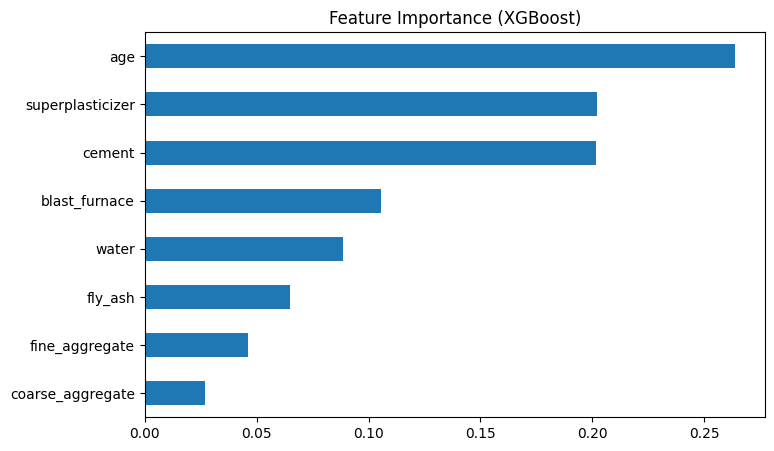

In [36]:
## cross validation
xgb_model = models["XGBoost"]
xgb_importances = pd.Series(xgb_model.feature_importances_, index=X.columns)
xgb_importances.sort_values().plot(kind='barh',figsize=(8,5),title= "Feature Importance (XGBoost)")
plt.show()


In [37]:
import numpy as np
cv = KFold(n_splits=5,shuffle=True,random_state=42)
scores = cross_val_score(xgb_model, X, y, cv=cv, scoring='r2')
print(f"XGBoost R2 score : {scores}")
print(f"Avg. R2 score : {np.mean(scores):.3f}")

XGBoost R2 score : [0.91384574 0.9090888  0.94431487 0.93915222 0.92997492]
Avg. R2 score : 0.927


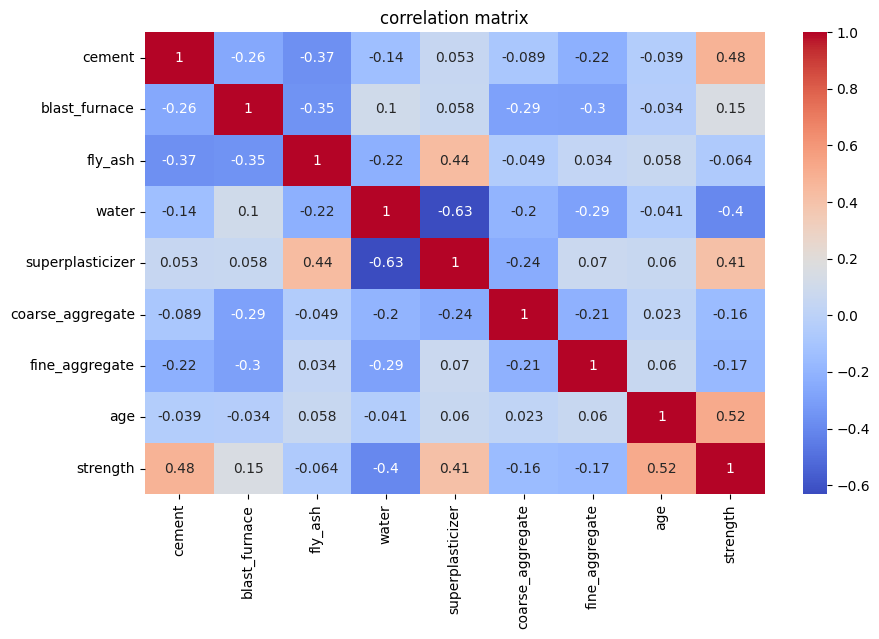

In [40]:
corr_matrix = df.corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix,annot=True,cmap="coolwarm")
plt.title("correlation matrix")
plt.show()

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

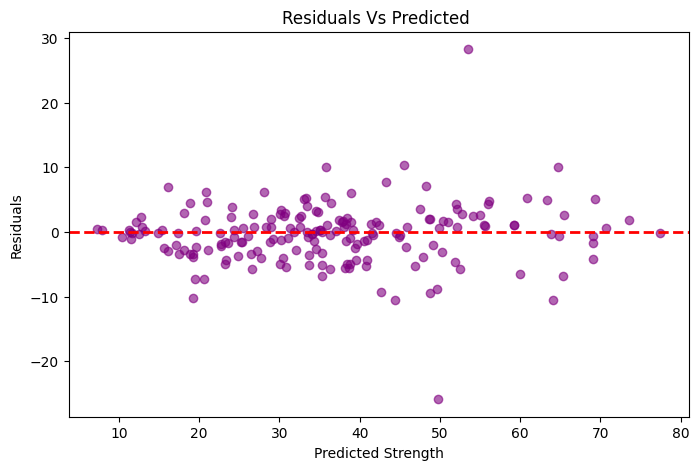

In [47]:
### Residual Error Plot
y_pred = xgb_model.predict(X_test)
residuals = y_test-y_pred

plt.figure(figsize=(8,5))
plt.scatter(y_pred,residuals, color='purple',alpha=0.6)
plt.axhline(y=0,color='red',linestyle='--',linewidth=2)
plt.xlabel("Predicted Strength")
plt.ylabel("Residuals")
plt.title("Residuals Vs Predicted ")
plt.show()

In [51]:
from sklearn.model_selection import learning_curve

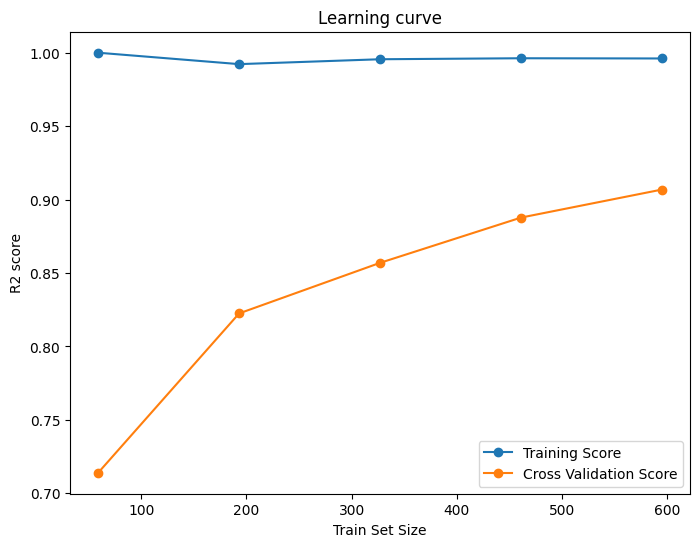

In [52]:
train_sizes, train_scores, test_scores = learning_curve(xgb_model,X_train, y_train, cv=5,
                                                        scoring = 'r2',train_sizes=np.linspace(0.1,1.0,5))
train_scores_mean = np.mean(train_scores,axis=1)
test_scores_mean = np.mean(test_scores,axis=1)
plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_scores_mean, "o-",label="Training Score")
plt.plot(train_sizes, test_scores_mean, "o-",label="Cross Validation Score")
plt.xlabel("Train Set Size")
plt.ylabel("R2 score")
plt.title("Learning curve")

plt.legend()
plt.show()

In [53]:
import shap

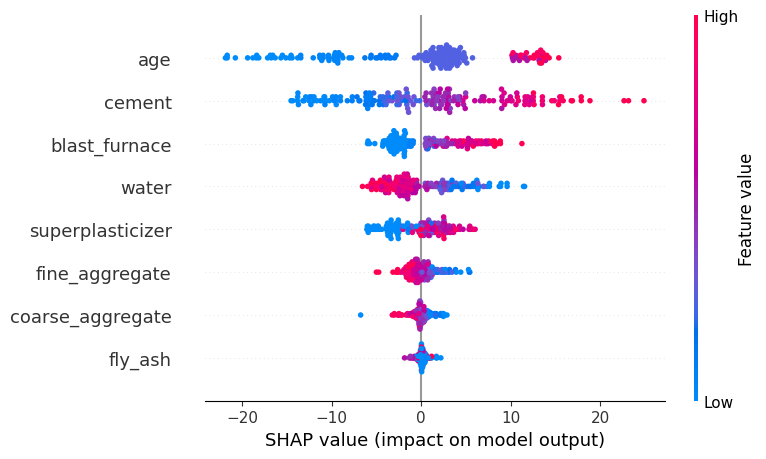

In [54]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test,feature_names=X.columns)

In [ ]:
## Neural Network

In [56]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 3891.8787 - val_loss: 822.1368
Epoch 2/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1131.2632 - val_loss: 287.5860
Epoch 3/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 646.8720 - val_loss: 390.8430
Epoch 4/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 523.5172 - val_loss: 186.8650
Epoch 5/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 485.4867 - val_loss: 325.0686
Epoch 6/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 353.2584 - val_loss: 180.9808
Epoch 7/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 314.8016 - val_loss: 184.1818
Epoch 8/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 256.3429 - val_loss: 242.2737
Epoch 9/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 246.2514 - val_loss: 193.2735
Epoch 10/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 206.7529 - val_loss: 148.0540
Epoch 11/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 238.8336 - val_loss: 127.0033
Epoch 12/100
47/4

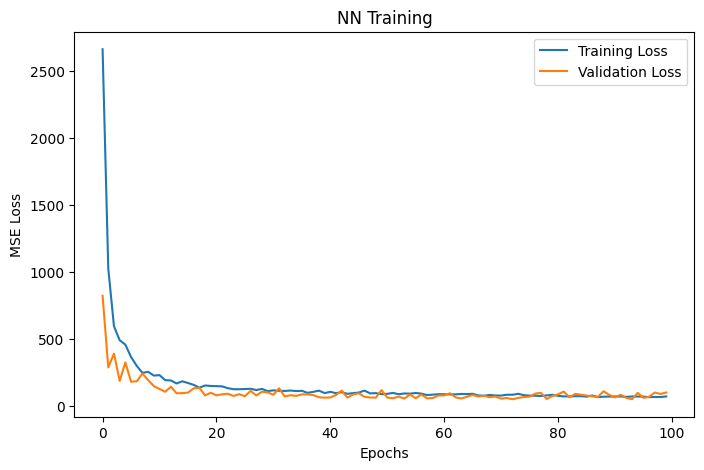

In [57]:
model = Sequential([
    Dense(64, activation='relu',input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(32,activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam',loss='mse')
history = model.fit(X_train,y_train,
                    validation_data = (X_test, y_test),
                    epochs=100,batch_size=16,verbose=1)
y_pred = model.predict(X_test).flatten()
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)
print(f"Neural Network - MSE: {mse:.3f}, RMSE: {rmse:.3f},, R2 score: {r2:.3f}")

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history["loss"],label="Training Loss")
plt.plot(history.history["val_loss"],label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("NN Training")
plt.legend()
plt.show()